# MassSpecGym Processing Check (gems_a_test)
This notebook verifies that MassSpecGym data is processed correctly using `configs/gems_a_test.py`.

In [1]:
import sys
from pathlib import Path

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from pathlib import Path
import importlib.util
import json
import csv

import numpy as np
import tensorflow as tf

import input_pipeline as ip

ROOT = Path('..').resolve()
CFG_PATH = ROOT / 'configs' / 'gems_a_test.py'

# Load config
spec = importlib.util.spec_from_file_location('cfg', CFG_PATH)
mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)
cfg = mod.get_config()
cfg.tfrecord_dir = "../" + cfg.tfrecord_dir

print('Config loaded:', CFG_PATH)
print('tfrecord_dir:', cfg.tfrecord_dir)


2026-02-05 06:40:52.255339: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-05 06:40:52.287440: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-05 06:40:53.118886: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Config loaded: /home/wuhao/spectra-learning/configs/gems_a_test.py
tfrecord_dir: ../data/gems_peaklist_tfrecord


/home/wuhao/spectra-learning/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Build the datamodule (loads/validates TFRecords if present)
module = ip.TfLightningDataModule(cfg, seed=int(cfg.seed))

print('MassSpec sizes from metadata:')
print('  train:', module.info['massspec_train_size'])
print('  val:', module.info['massspec_val_size'])
print('  test:', module.info['massspec_test_size'])


MassSpec sizes from metadata:
  train: 194119
  val: 19429
  test: 17556


In [3]:
# Verify TSV fold counts match metadata
meta_path = Path(module.info['tfrecord_dir']) / 'metadata.json'
metadata = json.loads(meta_path.read_text())

counts = {'train': 0, 'val': 0, 'test': 0}
with (ROOT / 'data' / 'data' / 'MassSpecGym.tsv').open() as f:
    reader = csv.DictReader(f, delimiter='	')
    for row in reader:
        counts[row['fold']] += 1

print('TSV counts:', counts)
print('Metadata counts:', {
    'train': metadata['massspec_train_size'],
    'val': metadata['massspec_val_size'],
    'test': metadata['massspec_test_size'],
})


TSV counts: {'train': 194119, 'val': 19429, 'test': 17556}
Metadata counts: {'train': 194119, 'val': 19429, 'test': 17556}


In [4]:
# Inspect one raw TFRecord example (fingerprint should be present)
file_path = module.massspec_train_files[0]
raw_ds = tf.data.TFRecordDataset([file_path], compression_type='GZIP')
for raw in raw_ds.take(1):
    ex = tf.train.Example()
    ex.ParseFromString(raw.numpy())
    feats = ex.features.feature
    print('raw mz len:', len(feats['mz'].float_list.value))
    print('raw intensity len:', len(feats['intensity'].float_list.value))
    print('raw fingerprint len:', len(feats['fingerprint'].int64_list.value))
    print('fingerprint unique values:', sorted(set(feats['fingerprint'].int64_list.value))[:5])


raw mz len: 128
raw intensity len: 128
raw fingerprint len: 1024
fingerprint unique values: [0, 1]


2026-02-05 06:41:03.495847: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:381] TFRecordDataset `buffer_size` is unspecified, default to 262144
2026-02-05 06:41:03.497221: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [5]:
# Verify processed batch (tokenization + masking) includes fingerprint in probe dataset
probe_ds = module.build_massspec_probe_dataset('massspec_train', seed=123)
batch = next(probe_ds.take(1).as_numpy_iterator())

print('batch keys:', batch.keys())
print('token_ids shape:', batch['token_ids'].shape)
print('segment_ids shape:', batch['segment_ids'].shape)
print('masked_token_ids shape:', batch['masked_token_ids'].shape)
print('mlm_mask shape:', batch['mlm_mask'].shape)
print('fingerprint shape:', batch['fingerprint'].shape)

vocab = module.info['vocab_size']
print('token_ids min/max:', batch['token_ids'].min(), batch['token_ids'].max())
print('vocab_size:', vocab)
print('token_ids within vocab:', batch['token_ids'].max() < vocab)


batch keys: dict_keys(['rt', 'precursor_mz', 'fingerprint', 'token_ids', 'segment_ids', 'masked_token_ids', 'mlm_mask'])
token_ids shape: (512, 128)
segment_ids shape: (512, 128)
masked_token_ids shape: (512, 128)
mlm_mask shape: (512, 128)
fingerprint shape: (512, 1024)
token_ids min/max: 0 1036
vocab_size: 1037
token_ids within vocab: True


2026-02-05 06:41:04.470490: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:387] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 250000


In [14]:
batch["masked_token_ids"][0]

array([   1,  236, 1008,   94, 1008,  218, 1008,    3, 1007,  124, 1007,
          3, 1006,  231,    3,    3, 1006,    3, 1006,  149, 1006,    3,
       1006,    3, 1006,   70, 1006,    3, 1006,    3, 1006,    3,    3,
          3, 1006,   87, 1006,   69, 1006,   78, 1006,    3, 1006,   60,
       1006,   90, 1006,   55,    3,   55,    3,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0], dtype=int32)

In [13]:
batch['mlm_mask'][0]

array([False, False, False, False, False, False, False,  True, False,
       False, False,  True, False, False,  True,  True, False,  True,
       False, False, False,  True, False,  True, False, False, False,
        True, False,  True, False,  True,  True,  True, False, False,
       False, False, False, False, False,  True, False, False, False,
       False, False, False,  True, False,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False]

In [6]:
# Sanity-check that standard MassSpec datasets do not include fingerprints
massspec_train_ds = module._build_massspec_train_dataset(seed=123)
train_batch = next(massspec_train_ds.take(1).as_numpy_iterator())
print('massspec train keys:', train_batch.keys())


massspec train keys: dict_keys(['rt', 'precursor_mz', 'token_ids', 'segment_ids', 'masked_token_ids', 'mlm_mask'])


## Visualize Raw MassSpecGym Spectra
Plots a few raw spectra directly from `data/data/MassSpecGym.tsv`.

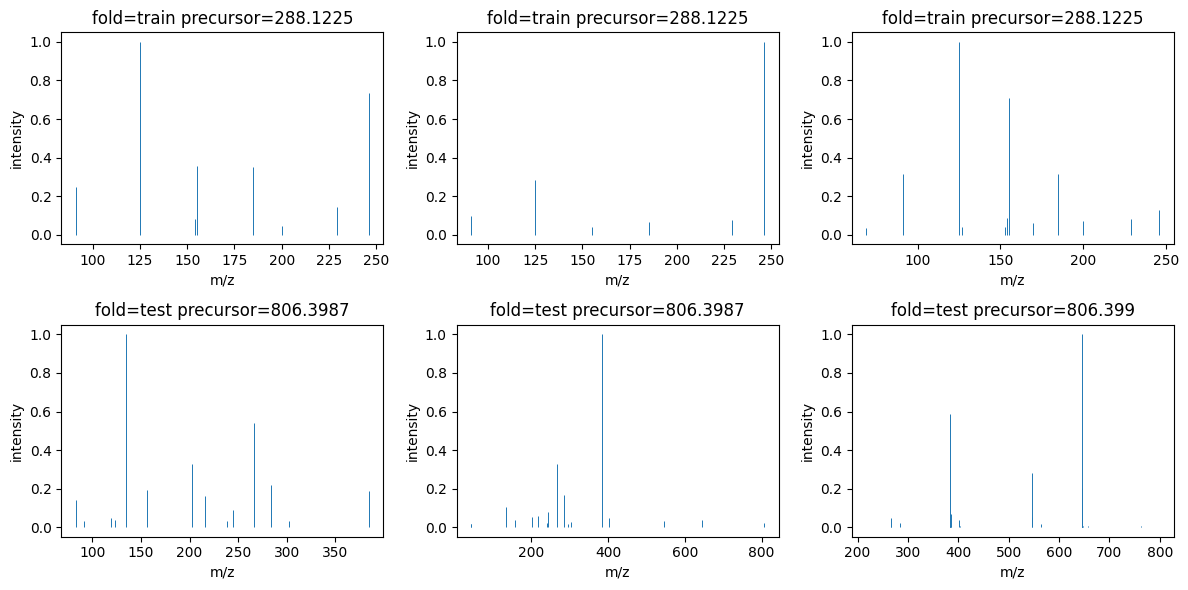

In [8]:
import csv
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path('..').resolve()
TSV_PATH = ROOT / 'data' / 'data' / 'MassSpecGym.tsv'

# Load a few spectra rows
rows = []
with TSV_PATH.open() as f:
    reader = csv.DictReader(f, delimiter='	')
    for i, row in enumerate(reader):
        if i < 3:
            rows.append(row)
        if i >= 200 and len(rows) < 6:
            rows.append(row)
        if len(rows) >= 6:
            break

fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=False, sharey=False)
axes = axes.flatten()

for ax, row in zip(axes, rows):
    mz = np.fromstring(row['mzs'], sep=',', dtype=np.float32)
    intensity = np.fromstring(row['intensities'], sep=',', dtype=np.float32)
    ax.vlines(mz, 0, intensity, color='#1f77b4', linewidth=0.7)
    ax.set_title(f"fold={row['fold']} precursor={row['precursor_mz']}")
    ax.set_xlabel('m/z')
    ax.set_ylabel('intensity')

plt.tight_layout()
plt.show()


## MLM Mask Sanity Check
Ensures we do not mask `[CLS]` or `[PAD]` tokens and that mask counts never exceed maskable positions.

In [9]:
import numpy as np

# Use a batch from the GeMS train dataset
train_ds = module._build_gems_train_dataset(seed=123)
batch = next(train_ds.take(1).as_numpy_iterator())

pad_id = cfg.pad_token_id
cls_id = cfg.cls_token_id

mask = batch['mlm_mask']
orig_ids = batch['token_ids']

masked_on_pad = np.logical_and(mask, orig_ids == pad_id).sum()
masked_on_cls = np.logical_and(mask, orig_ids == cls_id).sum()

mask_counts = mask.sum(axis=1)
maskable = np.logical_and(orig_ids != pad_id, orig_ids != cls_id)
maskable_counts = maskable.sum(axis=1)

print('masked_on_pad:', int(masked_on_pad))
print('masked_on_cls:', int(masked_on_cls))
print('mask_count min/max:', int(mask_counts.min()), int(mask_counts.max()))
print('maskable_count min/max:', int(maskable_counts.min()), int(maskable_counts.max()))
print('any mask_count > maskable_count:', bool((mask_counts > maskable_counts).any()))


masked_on_pad: 0
masked_on_cls: 0
mask_count min/max: 4 36
maskable_count min/max: 14 120
any mask_count > maskable_count: False


## MLM Mask Diversity Check
Checks that masks vary within a batch, across batches, and across epochs.

In [11]:
import numpy as np

seed = 123
val_ds = module._build_gems_val_dataset(seed=seed)

iter1 = val_ds.as_numpy_iterator()
b1 = next(iter1)['mlm_mask']
b2 = next(iter1)['mlm_mask']

# Within-batch uniqueness
packed1 = np.packbits(b1, axis=1)
unique_masks = np.unique(packed1, axis=0).shape[0]
print('within batch unique masks:', unique_masks, 'of', b1.shape[0])

# Across batches (same row index)
same_rows = np.all(b1 == b2, axis=1).sum()
print('same masks at same row index across batch1/batch2:', int(same_rows), 'of', b1.shape[0])

# Across epochs: new iterator on same dataset object
iter2 = val_ds.as_numpy_iterator()
b1_repeat = next(iter2)['mlm_mask']
print('same dataset object, first batch identical:', bool(np.array_equal(b1, b1_repeat)))

# Across epochs: rebuild dataset with same seed
val_ds_epoch2 = module._build_gems_val_dataset(seed=seed)
b1_epoch2 = next(val_ds_epoch2.as_numpy_iterator())['mlm_mask']
print('rebuild dataset, first batch identical:', bool(np.array_equal(b1, b1_epoch2)))


within batch unique masks: 512 of 512
same masks at same row index across batch1/batch2: 0 of 512
same dataset object, first batch identical: False
rebuild dataset, first batch identical: False
